In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

RAIZ = Path('..').resolve()
RUTA_ANALISIS = RAIZ / 'datos' / 'analisis'

# Estilo consistente
sns.set_theme(style='white')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

COLOR_HOMBRE = '#378ADD'
COLOR_MUJER  = '#D4537E'
COLOR_ROJO   = '#d62728'
COLOR_VERDE  = '#2ca02c'
COLOR_GRIS   = '#888888'

# Cargar los CSVs clave
bestr = pd.read_csv(RUTA_ANALISIS / 'brecha_estructural_2025.csv', encoding='utf-8-sig')
bsec  = pd.read_csv(RUTA_ANALISIS / 'brecha_sector_anio.csv', encoding='utf-8-sig')
bsec_ocu = pd.read_csv(RUTA_ANALISIS / 'brecha_sector_ocupacion_2025.csv', encoding='utf-8-sig')
bedu  = pd.read_csv(RUTA_ANALISIS / 'brecha_educ_sector_2025.csv', encoding='utf-8-sig')
best  = pd.read_csv(RUTA_ANALISIS / 'brecha_estado_sexo_2025.csv', encoding='utf-8-sig')
sn    = pd.read_csv(RUTA_ANALISIS / 'serie_nacional.csv', encoding='utf-8-sig')
sn_f  = pd.read_csv(RUTA_ANALISIS / 'serie_nacional_formal.csv', encoding='utf-8-sig')

print(f'brecha_estructural: {len(bestr):,} combinaciones únicas')
print(f'brecha_sector_ocupacion: {len(bsec_ocu):,} filas detalladas')

brecha_estructural: 3,664 combinaciones únicas
brecha_sector_ocupacion: 228,968 filas detalladas


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

# ============================================================
# RUTAS
# ============================================================

RAIZ = Path("..").resolve()
RUTA_ANALISIS = RAIZ / "datos" / "analisis"

# ============================================================
# COLORES
# ============================================================

COLOR_HOMBRE = "#378ADD"
COLOR_MUJER  = "#D4537E"
COLOR_ROJO   = "#D95F45"
COLOR_AZUL   = "#2C7FB8"
COLOR_VERDE  = "#2CA25F"
COLOR_GRIS   = "#6B7280"
COLOR_OSCURO = "#203864"

COLOR_MAPA_SEXO = {
    "Hombre": COLOR_HOMBRE,
    "Mujer": COLOR_MUJER
}

# ============================================================
# CONFIGURACIÓN PLOTLY
# ============================================================

px.defaults.template = "plotly_white"

FIG_CONFIG = {
    "displaylogo": False,
    "modeBarButtonsToRemove": [
        "select2d",
        "lasso2d",
        "autoScale2d"
    ],
    "toImageButtonOptions": {
        "format": "png",
        "filename": "grafica",
        "height": 700,
        "width": 1100,
        "scale": 2
    }
}

def estilo_fig(fig, titulo=None, subtitulo=None, alto=520):
    """
    Aplica estilo visual consistente a las gráficas.
    """
    if subtitulo:
        titulo_final = f"{titulo}<br><sup>{subtitulo}</sup>"
    else:
        titulo_final = titulo

    fig.update_layout(
        title={
            "text": titulo_final,
            "x": 0.02,
            "xanchor": "left",
            "font": {
                "size": 24,
                "color": COLOR_OSCURO
            }
        },
        font={
            "family": "Arial, sans-serif",
            "size": 14,
            "color": COLOR_OSCURO
        },
        height=alto,
        margin=dict(l=70, r=40, t=90, b=70),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.25,
            xanchor="left",
            x=0
        ),
        hoverlabel=dict(
            bgcolor="white",
            font_size=13,
            font_family="Arial"
        )
    )

    fig.update_xaxes(
        showgrid=True,
        gridcolor="#E5ECF6",
        zeroline=False
    )

    fig.update_yaxes(
        showgrid=True,
        gridcolor="#E5ECF6",
        zeroline=False
    )

    return fig

# ============================================================
# CARGA DE DATOS
# ============================================================

bestr = pd.read_csv(RUTA_ANALISIS / "brecha_estructural_2025.csv", encoding="utf-8-sig")
bsec  = pd.read_csv(RUTA_ANALISIS / "brecha_sector_anio.csv", encoding="utf-8-sig")
bsec_ocu = pd.read_csv(RUTA_ANALISIS / "brecha_sector_ocupacion_2025.csv", encoding="utf-8-sig")
bedu  = pd.read_csv(RUTA_ANALISIS / "brecha_educ_sector_2025.csv", encoding="utf-8-sig")
best  = pd.read_csv(RUTA_ANALISIS / "brecha_estado_sexo_2025.csv", encoding="utf-8-sig")
sn    = pd.read_csv(RUTA_ANALISIS / "serie_nacional.csv", encoding="utf-8-sig")
sn_f  = pd.read_csv(RUTA_ANALISIS / "serie_nacional_formal.csv", encoding="utf-8-sig")

print(f"brecha_estructural: {len(bestr):,} combinaciones únicas")
print(f"brecha_sector_ocupacion: {len(bsec_ocu):,} filas detalladas")
print(f"serie nacional: {len(sn):,} filas")

brecha_estructural: 3,664 combinaciones únicas
brecha_sector_ocupacion: 228,968 filas detalladas
serie nacional: 42 filas


In [11]:
bsec_ocu

,anio,estado,sector,ocupacion,nivel_educ,sexo,poblacion_ocupada,media_ing_hora,mediana_ing_hora
0,2005,Aguascalientes,Agropecuario,Actividades administrativas,Básica,Hombre,204,12.10,12.54545
1,2005,Aguascalientes,Agropecuario,Actividades administrativas,Media superior,Hombre,61,16.67,16.66667
2,2005,Aguascalientes,Agropecuario,Actividades agrícolas,Básica,Hombre,204,10.89,8.92857
3,2005,Aguascalientes,Agropecuario,Comerciantes y vendedores,Media superior,Hombre,126,38.58,34.93909
4,2005,Aguascalientes,Agropecuario,Funcionarios y directivos,Media superior,Hombre,211,18.64,17.70833
...,...,...,...,...,...,...,...,...,...
228963,2025,Zacatecas,Transportes y comunicaciones,Trabajadores de la educación,Superior,Hombre,57,39.68,39.68254
228964,2025,Zacatecas,Transportes y comunicaciones,Trabajadores del arte,Media superior,Hombre,72,37.50,37.50000
228965,2025,Zacatecas,Transportes y comunicaciones,Trabajadores del arte,Media superior,Mujer,203,58.00,83.75000
228966,2025,Zacatecas,Transportes y comunicaciones,Trabajadores del arte,Superior,Hombre,262,18.75,18.75000


In [2]:
# Filtrar celdas con muestra suficiente para ser confiables
# Necesitamos que cada combinación tenga al menos X personas representadas
bestr_clean = bestr.dropna(subset=['Hombre', 'Mujer', 'brecha_pct']).copy()

# Remover outliers extremos (probablemente muestras muy pequeñas)
# Mantener solo brechas entre -100% y 100%
bestr_clean = bestr_clean[bestr_clean['brecha_pct'].between(-100, 100)]

print(f'Combinaciones válidas para análisis estructural: {len(bestr_clean):,}')
print()

# Estadísticos clave
brecha_estructural_media = bestr_clean['brecha_pct'].mean()
brecha_estructural_mediana = bestr_clean['brecha_pct'].median()
pct_desfavorables_mujeres = (bestr_clean['brecha_pct'] > 0).mean() * 100
pct_favorables_mujeres = (bestr_clean['brecha_pct'] < 0).mean() * 100

print('=' * 60)
print('   BRECHA ESTRUCTURAL — CONTROL POR 4 VARIABLES')
print('   (estado × sector × ocupación × nivel educativo)')
print('=' * 60)
print(f'Brecha media:      {brecha_estructural_media:.1f}%')
print(f'Brecha mediana:    {brecha_estructural_mediana:.1f}%')
print(f'% celdas donde H>M: {pct_desfavorables_mujeres:.1f}%')
print(f'% celdas donde M>H: {pct_favorables_mujeres:.1f}%')
print()
print('INTERPRETACIÓN:')
print(f'En {pct_desfavorables_mujeres:.0f}% de las combinaciones estado-sector-ocupación-educación,')
print(f'los hombres ganan más que las mujeres. La brecha persiste incluso')
print(f'cuando comparamos personas con el mismo cargo, misma educación,')
print(f'mismo sector y mismo estado.')

Combinaciones válidas para análisis estructural: 3,402

   BRECHA ESTRUCTURAL — CONTROL POR 4 VARIABLES
   (estado × sector × ocupación × nivel educativo)
Brecha media:      4.0%
Brecha mediana:    7.0%
% celdas donde H>M: 57.7%
% celdas donde M>H: 39.7%

INTERPRETACIÓN:
En 58% de las combinaciones estado-sector-ocupación-educación,
los hombres ganan más que las mujeres. La brecha persiste incluso
cuando comparamos personas con el mismo cargo, misma educación,
mismo sector y mismo estado.


In [2]:
# ============================================================
# LIMPIEZA DE BRECHA ESTRUCTURAL
# ============================================================

bestr_clean = bestr.dropna(subset=["Hombre", "Mujer", "brecha_pct"]).copy()

# Mantener rango interpretable. Valores fuera de este rango suelen venir de
# combinaciones pequeñas o ingresos muy atípicos.
bestr_clean = bestr_clean[bestr_clean["brecha_pct"].between(-100, 100)].copy()

# Clasificación narrativa
bestr_clean["sentido_brecha"] = np.select(
    [
        bestr_clean["brecha_pct"] > 0,
        bestr_clean["brecha_pct"] < 0
    ],
    [
        "Hombres ganan más",
        "Mujeres ganan más"
    ],
    default="Paridad exacta"
)

# Métricas principales
brecha_estructural_media = bestr_clean["brecha_pct"].mean()
brecha_estructural_mediana = bestr_clean["brecha_pct"].median()
pct_desfavorables_mujeres = (bestr_clean["brecha_pct"] > 0).mean() * 100
pct_favorables_mujeres = (bestr_clean["brecha_pct"] < 0).mean() * 100
pct_paridad_exacta = (bestr_clean["brecha_pct"] == 0).mean() * 100

n_total = len(bestr)
n_validas = len(bestr_clean)

display(Markdown(f"""
## Lectura rápida del análisis estructural

Se comparan combinaciones de:

**estado × sector × ocupación × nivel educativo**

| Indicador | Valor |
|---|---:|
| Combinaciones originales | {n_total:,} |
| Combinaciones válidas | {n_validas:,} |
| Brecha media | {brecha_estructural_media:.1f}% |
| Brecha mediana | {brecha_estructural_mediana:.1f}% |
| Combinaciones donde hombres ganan más | {pct_desfavorables_mujeres:.1f}% |
| Combinaciones donde mujeres ganan más | {pct_favorables_mujeres:.1f}% |

**Interpretación central:**  
En casi **{pct_desfavorables_mujeres:.0f}%** de las combinaciones comparables, los hombres ganan más que las mujeres.  
Esto sugiere que la brecha persiste incluso cuando se compara dentro del mismo estado, sector, ocupación y nivel educativo.
"""))


## Lectura rápida del análisis estructural

Se comparan combinaciones de:

**estado × sector × ocupación × nivel educativo**

| Indicador | Valor |
|---|---:|
| Combinaciones originales | 3,664 |
| Combinaciones válidas | 3,402 |
| Brecha media | 4.0% |
| Brecha mediana | 7.0% |
| Combinaciones donde hombres ganan más | 57.7% |
| Combinaciones donde mujeres ganan más | 39.7% |

**Interpretación central:**  
En casi **58%** de las combinaciones comparables, los hombres ganan más que las mujeres.  
Esto sugiere que la brecha persiste incluso cuando se compara dentro del mismo estado, sector, ocupación y nivel educativo.


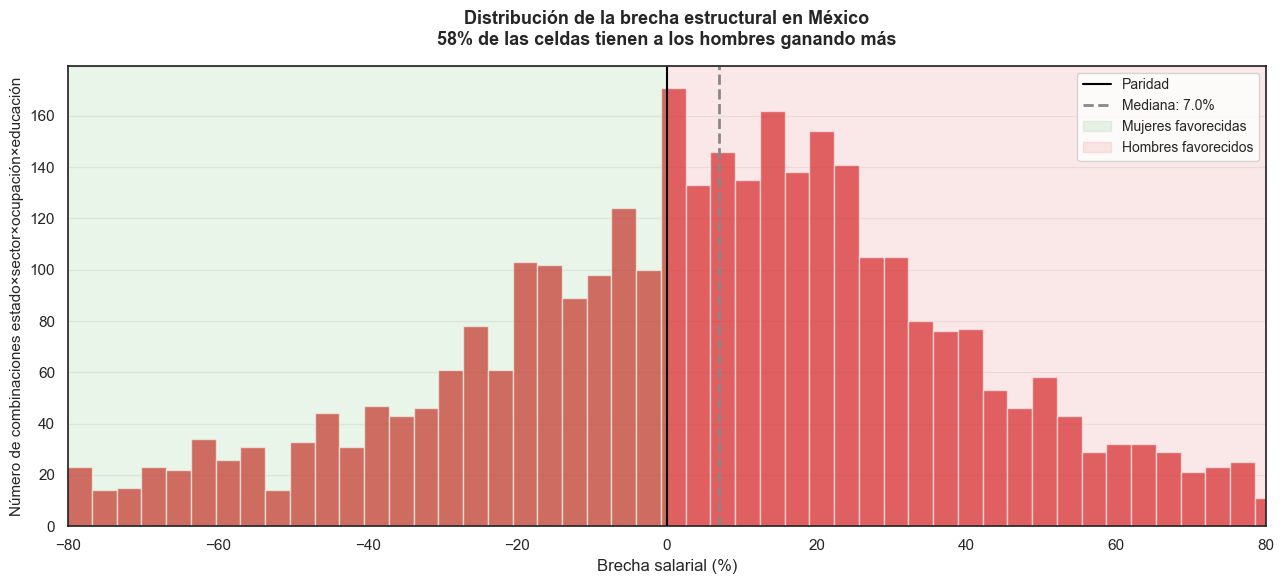

In [3]:
fig, ax = plt.subplots(figsize=(13, 6))

# Histograma de brechas
ax.hist(bestr_clean['brecha_pct'], bins=60, 
        color=COLOR_ROJO, alpha=0.7, edgecolor='white')

# Líneas de referencia
ax.axvline(0, color='black', linewidth=1.5, label='Paridad')
ax.axvline(brecha_estructural_mediana, color=COLOR_GRIS, linestyle='--', 
           linewidth=2, label=f'Mediana: {brecha_estructural_mediana:.1f}%')

# Áreas sombreadas
ax.axvspan(-100, 0, alpha=0.1, color=COLOR_VERDE, label='Mujeres favorecidas')
ax.axvspan(0, 100, alpha=0.1, color=COLOR_ROJO, label='Hombres favorecidos')

ax.set_xlabel('Brecha salarial (%)', fontsize=12)
ax.set_ylabel('Número de combinaciones estado×sector×ocupación×educación', fontsize=11)
ax.set_title(f'Distribución de la brecha estructural en México\n'
             f'{pct_desfavorables_mujeres:.0f}% de las celdas tienen a los hombres ganando más',
             fontsize=13, pad=15)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(-80, 80)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('brecha_estructural_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

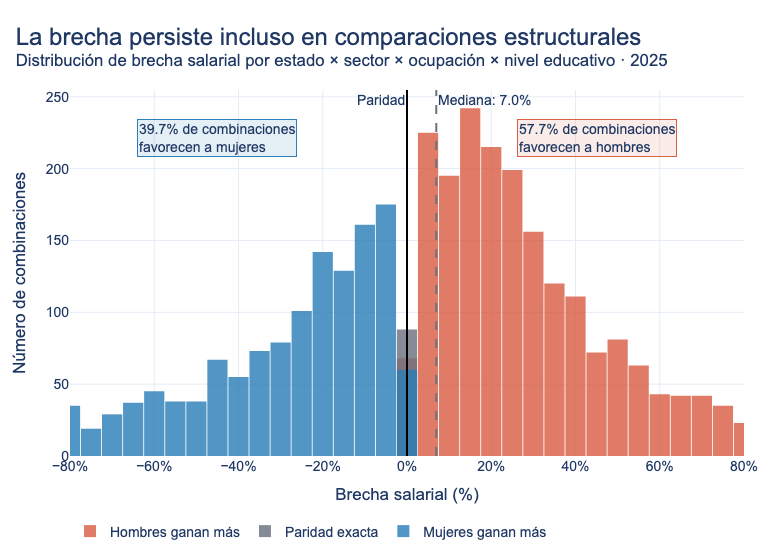

In [3]:
fig_dist = px.histogram(
    bestr_clean,
    x="brecha_pct",
    color="sentido_brecha",
    nbins=70,
    color_discrete_map={
        "Hombres ganan más": COLOR_ROJO,
        "Mujeres ganan más": COLOR_AZUL,
        "Paridad exacta": COLOR_GRIS
    },
    labels={
        "brecha_pct": "Brecha salarial (%)",
        "count": "Número de combinaciones",
        "sentido_brecha": ""
    },
    hover_data={
        "brecha_pct": ":.1f",
        "sentido_brecha": True
    }
)

fig_dist.add_vline(
    x=0,
    line_width=2,
    line_color="black",
    annotation_text="Paridad",
    annotation_position="top left"
)

fig_dist.add_vline(
    x=brecha_estructural_mediana,
    line_width=2,
    line_dash="dash",
    line_color=COLOR_GRIS,
    annotation_text=f"Mediana: {brecha_estructural_mediana:.1f}%",
    annotation_position="top right"
)

fig_dist.add_annotation(
    x=45,
    y=0.92,
    xref="x",
    yref="paper",
    text=f"{pct_desfavorables_mujeres:.1f}% de combinaciones<br>favorecen a hombres",
    showarrow=False,
    align="left",
    bgcolor="rgba(217,95,69,0.12)",
    bordercolor=COLOR_ROJO,
    borderwidth=1,
    font=dict(size=14, color=COLOR_OSCURO)
)

fig_dist.add_annotation(
    x=-45,
    y=0.92,
    xref="x",
    yref="paper",
    text=f"{pct_favorables_mujeres:.1f}% de combinaciones<br>favorecen a mujeres",
    showarrow=False,
    align="left",
    bgcolor="rgba(44,127,184,0.12)",
    bordercolor=COLOR_AZUL,
    borderwidth=1,
    font=dict(size=14, color=COLOR_OSCURO)
)

fig_dist.update_layout(
    bargap=0.04,
    barmode="overlay"
)

fig_dist.update_traces(opacity=0.82)

fig_dist = estilo_fig(
    fig_dist,
    titulo="La brecha persiste incluso en comparaciones estructurales",
    subtitulo="Distribución de brecha salarial por estado × sector × ocupación × nivel educativo · 2025",
    alto=560
)

fig_dist.update_xaxes(range=[-80, 80], ticksuffix="%")
fig_dist.update_yaxes(title="Número de combinaciones")

fig_dist.show(config=FIG_CONFIG)

In [4]:
# Filtrar celdas con muestra robusta
islas_paridad = bestr_clean[bestr_clean['brecha_pct'] <= 0].copy()

print(f'Islas de paridad (brecha ≤ 0): {len(islas_paridad):,} combinaciones')
print()

# Sectores donde más aparecen las mujeres favorecidas
print('TOP 5 SECTORES CON MÁS ISLAS DE PARIDAD:')
top_sectores_paridad = islas_paridad.groupby('sector').size().sort_values(ascending=False).head(5)
print(top_sectores_paridad)
print()

# Ocupaciones donde más aparecen
print('TOP 5 OCUPACIONES CON MÁS ISLAS DE PARIDAD:')
top_ocup_paridad = islas_paridad.groupby('ocupacion').size().sort_values(ascending=False).head(5)
print(top_ocup_paridad)
print()

# Nivel educativo
print('DISTRIBUCIÓN POR NIVEL EDUCATIVO:')
print(islas_paridad.groupby('nivel_educ').size().sort_values(ascending=False))

Islas de paridad (brecha ≤ 0): 1,440 combinaciones

TOP 5 SECTORES CON MÁS ISLAS DE PARIDAD:
sector
Servicios diversos                       245
Restaurantes y hospedaje                 240
Comercio                                 191
Servicios financieros y profesionales    174
Manufactura                              136
dtype: int64

TOP 5 OCUPACIONES CON MÁS ISLAS DE PARIDAD:
ocupacion
Actividades agrícolas          403
Actividades administrativas    238
Comerciantes y vendedores      234
Trabajadores del arte          190
Funcionarios y directivos      149
dtype: int64

DISTRIBUCIÓN POR NIVEL EDUCATIVO:
nivel_educ
Superior           511
Media superior     461
Básica             280
Sin instrucción    181
No especificado      7
dtype: int64


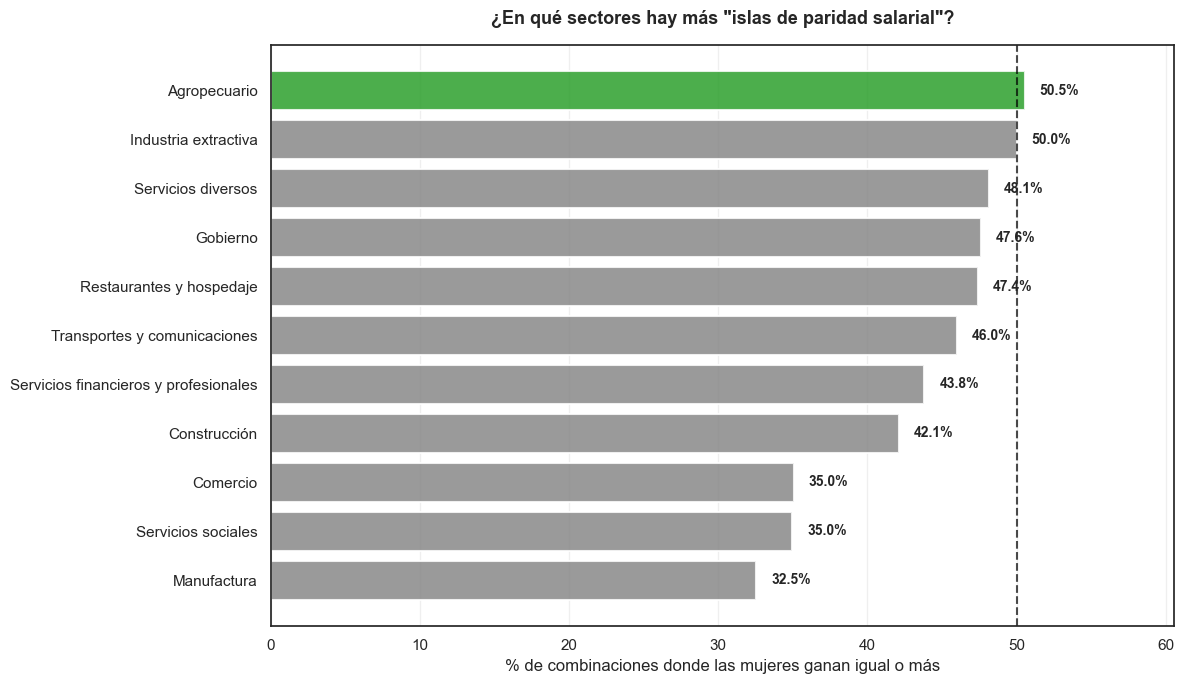

In [5]:
# Para cada sector, qué porcentaje de sus celdas son "islas de paridad"
pct_paridad_sector = bestr_clean.groupby('sector').apply(
    lambda x: (x['brecha_pct'] <= 0).mean() * 100
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

colores = [COLOR_VERDE if v > 50 else COLOR_ROJO if v < 30 else COLOR_GRIS 
           for v in pct_paridad_sector.values]

bars = ax.barh(range(len(pct_paridad_sector)), pct_paridad_sector.values,
               color=colores, alpha=0.85, edgecolor='white', linewidth=1.5)

ax.axvline(50, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(range(len(pct_paridad_sector)))
ax.set_yticklabels(pct_paridad_sector.index)

# Etiquetas
for bar, val in zip(bars, pct_paridad_sector.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('% de combinaciones donde las mujeres ganan igual o más', fontsize=12)
ax.set_title('¿En qué sectores hay más "islas de paridad salarial"?',
             fontsize=13, pad=15)
ax.set_xlim(0, max(pct_paridad_sector.values) + 10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('islas_paridad_sector.png', dpi=150, bbox_inches='tight')
plt.show()

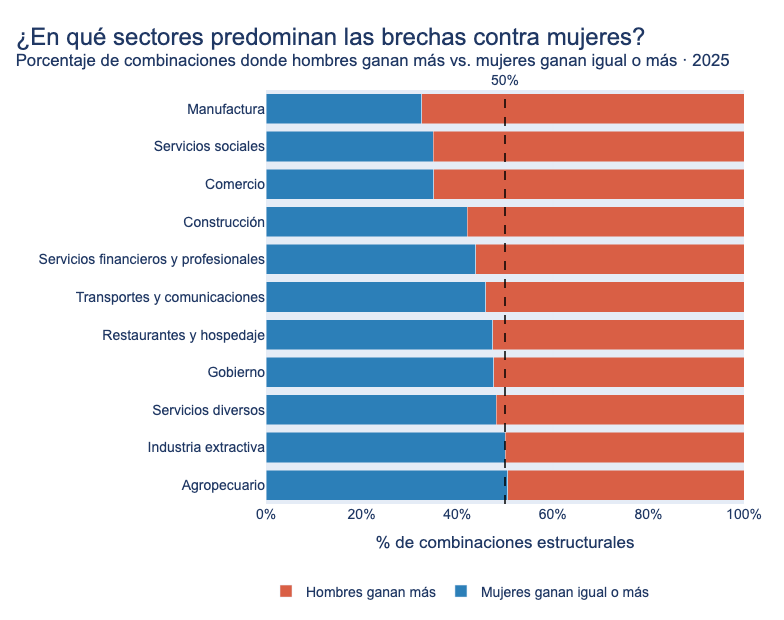

In [4]:
res_sector = (
    bestr_clean
    .groupby("sector")
    .agg(
        total=("brecha_pct", "size"),
        brecha_mediana=("brecha_pct", "median"),
        pct_hombres_mas=("brecha_pct", lambda x: (x > 0).mean() * 100),
        pct_mujeres_igual_o_mas=("brecha_pct", lambda x: (x <= 0).mean() * 100)
    )
    .reset_index()
)

res_sector = res_sector.sort_values("pct_hombres_mas", ascending=True)

fig_paridad = go.Figure()

fig_paridad.add_trace(
    go.Bar(
        y=res_sector["sector"],
        x=res_sector["pct_mujeres_igual_o_mas"],
        name="Mujeres ganan igual o más",
        orientation="h",
        marker=dict(color=COLOR_AZUL),
        customdata=np.stack(
            [
                res_sector["total"],
                res_sector["brecha_mediana"]
            ],
            axis=-1
        ),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Mujeres igual o más: %{x:.1f}%<br>"
            "Combinaciones: %{customdata[0]:,.0f}<br>"
            "Brecha mediana: %{customdata[1]:.1f}%"
            "<extra></extra>"
        )
    )
)

fig_paridad.add_trace(
    go.Bar(
        y=res_sector["sector"],
        x=res_sector["pct_hombres_mas"],
        name="Hombres ganan más",
        orientation="h",
        marker=dict(color=COLOR_ROJO),
        customdata=np.stack(
            [
                res_sector["total"],
                res_sector["brecha_mediana"]
            ],
            axis=-1
        ),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Hombres ganan más: %{x:.1f}%<br>"
            "Combinaciones: %{customdata[0]:,.0f}<br>"
            "Brecha mediana: %{customdata[1]:.1f}%"
            "<extra></extra>"
        )
    )
)

fig_paridad.add_vline(
    x=50,
    line_dash="dash",
    line_color="black",
    line_width=1.5,
    annotation_text="50%",
    annotation_position="top"
)

fig_paridad.update_layout(
    barmode="stack",
    xaxis=dict(
        title="% de combinaciones estructurales",
        range=[0, 100],
        ticksuffix="%"
    ),
    yaxis=dict(title=""),
)

fig_paridad = estilo_fig(
    fig_paridad,
    titulo="¿En qué sectores predominan las brechas contra mujeres?",
    subtitulo="Porcentaje de combinaciones donde hombres ganan más vs. mujeres ganan igual o más · 2025",
    alto=620
)

fig_paridad.show(config=FIG_CONFIG)

In [6]:
# Calcular brecha por año
pivot_sn = sn.pivot(index='anio', columns='sexo', values='mediana_ing_hora').reset_index()
pivot_sn['brecha_pct'] = ((pivot_sn['Hombre'] - pivot_sn['Mujer']) / pivot_sn['Hombre'] * 100).round(2)

print('Evolución de la brecha salarial nacional 2005-2025:')
print(pivot_sn.to_string(index=False))

# Cambio punto inicial vs final
cambio = pivot_sn.iloc[-1]['brecha_pct'] - pivot_sn.iloc[0]['brecha_pct']
print(f'\nCambio 2005 → 2025: {cambio:+.1f} puntos porcentuales')

Evolución de la brecha salarial nacional 2005-2025:
 anio  Hombre  Mujer  brecha_pct
 2005   16.67  15.50        7.02
 2006   17.92  16.67        6.98
 2007   19.38  17.78        8.26
 2008   20.00  18.52        7.40
 2009   20.00  18.75        6.25
 2010   20.00  19.38        3.10
 2011   20.83  20.00        3.98
 2012   21.43  20.00        6.67
 2013   22.22  20.83        6.26
 2014   22.50  21.11        6.18
 2015   23.33  22.22        4.76
 2016   25.00  23.57        5.72
 2017   25.68  25.00        2.65
 2018   27.56  25.97        5.77
 2019   29.17  27.78        4.77
 2020   31.25  30.00        4.00
 2021   33.33  31.91        4.26
 2022   36.00  33.33        7.42
 2023   40.00  37.50        6.25
 2024   44.44  42.00        5.49
 2025   50.00  46.51        6.98

Cambio 2005 → 2025: -0.0 puntos porcentuales


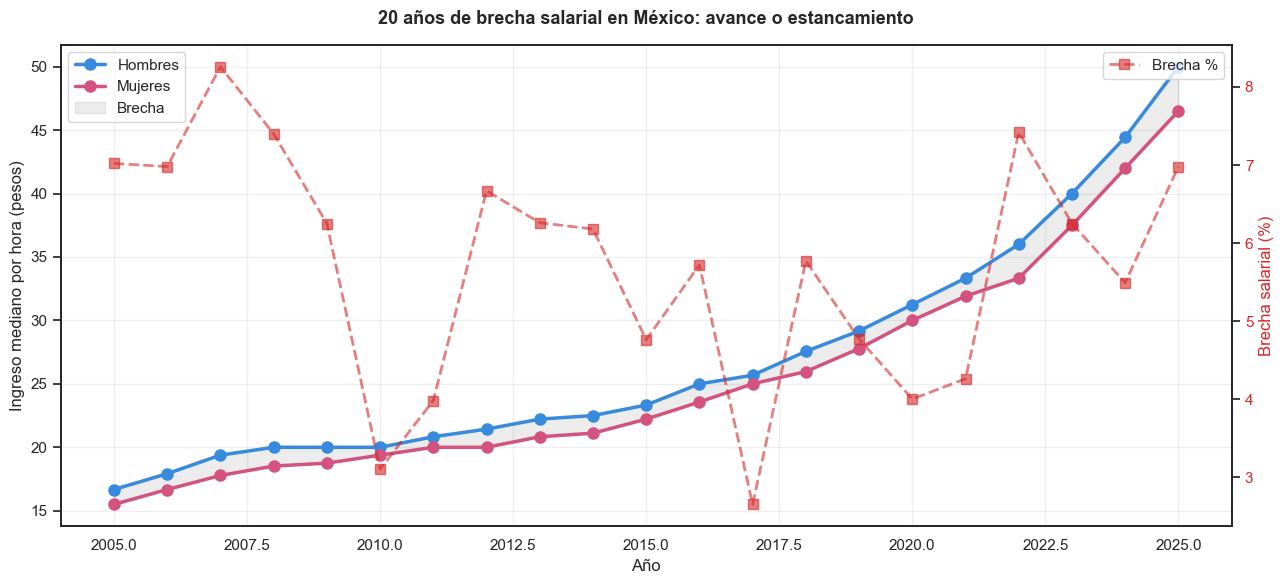

In [7]:
fig, ax1 = plt.subplots(figsize=(13, 6))

# Ingresos H y M
ax1.plot(pivot_sn['anio'], pivot_sn['Hombre'], 
         marker='o', color=COLOR_HOMBRE, linewidth=2.5, 
         markersize=8, label='Hombres')
ax1.plot(pivot_sn['anio'], pivot_sn['Mujer'], 
         marker='o', color=COLOR_MUJER, linewidth=2.5, 
         markersize=8, label='Mujeres')

ax1.fill_between(pivot_sn['anio'], pivot_sn['Hombre'], pivot_sn['Mujer'],
                 alpha=0.15, color='gray', label='Brecha')

ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Ingreso mediano por hora (pesos)', fontsize=12)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(alpha=0.3)

# Segundo eje para la brecha %
ax2 = ax1.twinx()
ax2.plot(pivot_sn['anio'], pivot_sn['brecha_pct'], 
         marker='s', color=COLOR_ROJO, linewidth=2, 
         markersize=7, linestyle='--', alpha=0.6,
         label='Brecha %')
ax2.set_ylabel('Brecha salarial (%)', fontsize=12, color=COLOR_ROJO)
ax2.tick_params(axis='y', labelcolor=COLOR_ROJO)
ax2.legend(loc='upper right', fontsize=11)

plt.title('20 años de brecha salarial en México: avance o estancamiento',
          fontsize=13, pad=15)
plt.tight_layout()
#plt.savefig('evolucion_brecha_2005_2025.png', dpi=150, bbox_inches='tight')
plt.show()

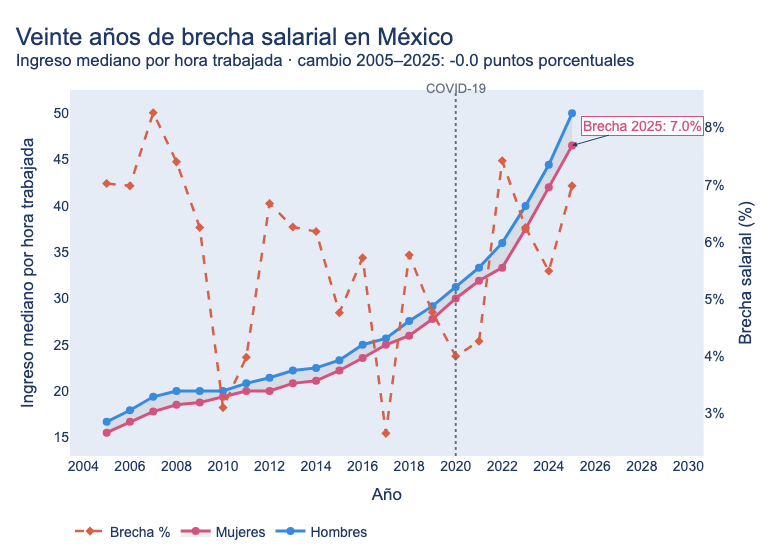

In [6]:
pivot_sn = (
    sn
    .pivot(index="anio", columns="sexo", values="mediana_ing_hora")
    .reset_index()
)

pivot_sn["brecha_pct"] = (
    (pivot_sn["Hombre"] - pivot_sn["Mujer"]) / pivot_sn["Hombre"] * 100
).round(2)

cambio_2005_2025 = (
    pivot_sn.loc[pivot_sn["anio"] == 2025, "brecha_pct"].iloc[0]
    - pivot_sn.loc[pivot_sn["anio"] == 2005, "brecha_pct"].iloc[0]
)

fig_evol = make_subplots(specs=[[{"secondary_y": True}]])

# Línea hombres
fig_evol.add_trace(
    go.Scatter(
        x=pivot_sn["anio"],
        y=pivot_sn["Hombre"],
        mode="lines+markers",
        name="Hombres",
        line=dict(color=COLOR_HOMBRE, width=3),
        marker=dict(size=8),
        hovertemplate="Año: %{x}<br>Hombres: $%{y:.2f}/hora<extra></extra>"
    ),
    secondary_y=False
)

# Línea mujeres con relleno hacia hombres
fig_evol.add_trace(
    go.Scatter(
        x=pivot_sn["anio"],
        y=pivot_sn["Mujer"],
        mode="lines+markers",
        name="Mujeres",
        line=dict(color=COLOR_MUJER, width=3),
        marker=dict(size=8),
        fill="tonexty",
        fillcolor="rgba(107,114,128,0.12)",
        hovertemplate="Año: %{x}<br>Mujeres: $%{y:.2f}/hora<extra></extra>"
    ),
    secondary_y=False
)

# Brecha %
fig_evol.add_trace(
    go.Scatter(
        x=pivot_sn["anio"],
        y=pivot_sn["brecha_pct"],
        mode="lines+markers",
        name="Brecha %",
        line=dict(color=COLOR_ROJO, width=2.5, dash="dash"),
        marker=dict(size=7, symbol="diamond"),
        hovertemplate="Año: %{x}<br>Brecha: %{y:.1f}%<extra></extra>"
    ),
    secondary_y=True
)

fig_evol.add_vline(
    x=2020,
    line_dash="dot",
    line_color=COLOR_GRIS,
    line_width=2
)

fig_evol.add_annotation(
    x=2020,
    y=1.03,
    xref="x",
    yref="paper",
    text="COVID-19",
    showarrow=False,
    font=dict(color=COLOR_GRIS, size=13)
)

brecha_2025 = pivot_sn.loc[pivot_sn["anio"] == 2025, "brecha_pct"].iloc[0]

fig_evol.add_annotation(
    x=2025,
    y=pivot_sn.loc[pivot_sn["anio"] == 2025, "Mujer"].iloc[0],
    text=f"Brecha 2025: {brecha_2025:.1f}%",
    showarrow=True,
    arrowhead=2,
    ax=70,
    ay=-20,
    bgcolor="rgba(255,255,255,0.85)",
    bordercolor=COLOR_MUJER,
    borderwidth=1,
    font=dict(color=COLOR_MUJER, size=14)
)

fig_evol.update_yaxes(
    title_text="Ingreso mediano por hora trabajada",
    secondary_y=False
)

fig_evol.update_yaxes(
    title_text="Brecha salarial (%)",
    secondary_y=True,
    ticksuffix="%",
    showgrid=False
)

fig_evol.update_xaxes(
    title_text="Año",
    dtick=2
)

fig_evol = estilo_fig(
    fig_evol,
    titulo="Veinte años de brecha salarial en México",
    subtitulo=f"Ingreso mediano por hora trabajada · cambio 2005–2025: {cambio_2005_2025:+.1f} puntos porcentuales",
    alto=560
)

fig_evol.show(config=FIG_CONFIG)

In [8]:
# Ver qué años tiene disponible
años_disponibles = sorted(bsec['anio'].unique())
print(f'Años disponibles: {años_disponibles}')

# Si tiene 2005 y 2025, hacer el análisis de transformación
if 2005 in años_disponibles and 2025 in años_disponibles:
    b2005 = bsec[bsec['anio'] == 2005].set_index('sector')[['brecha_pct']]
    b2025 = bsec[bsec['anio'] == 2025].set_index('sector')[['brecha_pct']]
    
    comparacion = b2005.join(b2025, lsuffix='_2005', rsuffix='_2025')
    comparacion['cambio'] = comparacion['brecha_pct_2025'] - comparacion['brecha_pct_2005']
    comparacion = comparacion.sort_values('cambio')
    
    print('Cambio de brecha por sector entre 2005 y 2025:')
    print(comparacion.round(1).to_string())
else:
    # Si solo tiene años recientes, usar el primero y último disponibles
    año_ini, año_fin = años_disponibles[0], años_disponibles[-1]
    b_ini = bsec[bsec['anio'] == año_ini].set_index('sector')[['brecha_pct']]
    b_fin = bsec[bsec['anio'] == año_fin].set_index('sector')[['brecha_pct']]
    
    comparacion = b_ini.join(b_fin, lsuffix=f'_{año_ini}', rsuffix=f'_{año_fin}')
    comparacion['cambio'] = comparacion[f'brecha_pct_{año_fin}'] - comparacion[f'brecha_pct_{año_ini}']
    print(f'Comparación {año_ini} vs {año_fin}:')
    print(comparacion.round(1).to_string())

Años disponibles: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Cambio de brecha por sector entre 2005 y 2025:
                                       brecha_pct_2005  brecha_pct_2025  cambio
sector                                                                         
Industria extractiva                              -0.1            -40.6   -40.5
Transportes y comunicaciones                       4.2            -21.4   -25.6
Restaurantes y hospedaje                          16.7              4.0   -12.7
Manufactura                                       31.4             20.0   -11.4
Comercio                                          20.3             11.1    -9.2
Servicios financieros y profesionales 

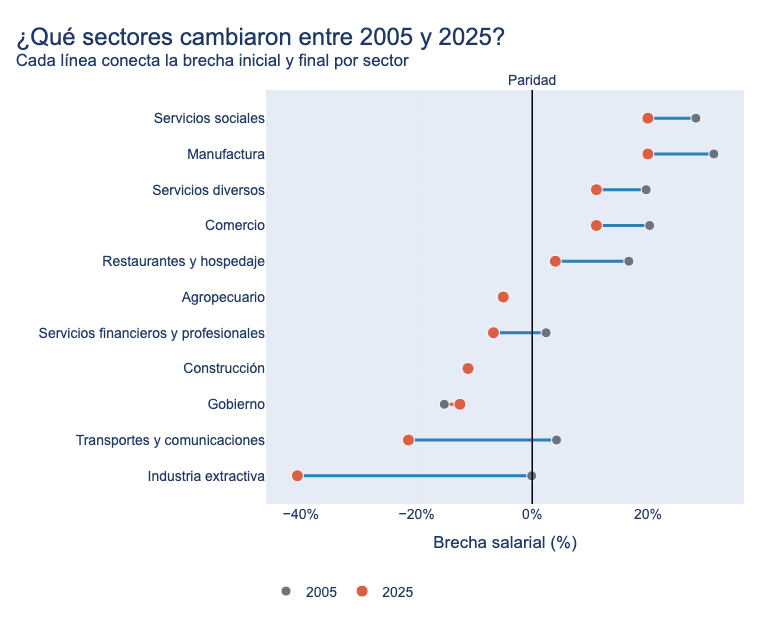

In [7]:
años_disponibles = sorted(bsec["anio"].dropna().unique())

anio_ini = 2005 if 2005 in años_disponibles else años_disponibles[0]
anio_fin = 2025 if 2025 in años_disponibles else años_disponibles[-1]

b_ini = (
    bsec[bsec["anio"] == anio_ini]
    .set_index("sector")[["brecha_pct"]]
    .rename(columns={"brecha_pct": f"brecha_{anio_ini}"})
)

b_fin = (
    bsec[bsec["anio"] == anio_fin]
    .set_index("sector")[["brecha_pct"]]
    .rename(columns={"brecha_pct": f"brecha_{anio_fin}"})
)

comparacion = b_ini.join(b_fin, how="inner").reset_index()
comparacion["cambio"] = comparacion[f"brecha_{anio_fin}"] - comparacion[f"brecha_{anio_ini}"]

comparacion = comparacion.sort_values(f"brecha_{anio_fin}", ascending=True)

fig_dumbbell = go.Figure()

for _, row in comparacion.iterrows():
    color_linea = COLOR_ROJO if row["cambio"] > 0 else COLOR_AZUL

    fig_dumbbell.add_trace(
        go.Scatter(
            x=[row[f"brecha_{anio_ini}"], row[f"brecha_{anio_fin}"]],
            y=[row["sector"], row["sector"]],
            mode="lines",
            line=dict(color=color_linea, width=3),
            showlegend=False,
            hoverinfo="skip"
        )
    )

fig_dumbbell.add_trace(
    go.Scatter(
        x=comparacion[f"brecha_{anio_ini}"],
        y=comparacion["sector"],
        mode="markers",
        name=str(anio_ini),
        marker=dict(color=COLOR_GRIS, size=10, line=dict(color="white", width=1)),
        customdata=comparacion[["cambio"]],
        hovertemplate=(
            "<b>%{y}</b><br>"
            f"Brecha {anio_ini}: %{{x:.1f}}%<br>"
            "Cambio total: %{customdata[0]:+.1f} pp"
            "<extra></extra>"
        )
    )
)

fig_dumbbell.add_trace(
    go.Scatter(
        x=comparacion[f"brecha_{anio_fin}"],
        y=comparacion["sector"],
        mode="markers",
        name=str(anio_fin),
        marker=dict(color=COLOR_ROJO, size=12, line=dict(color="white", width=1)),
        customdata=comparacion[["cambio"]],
        hovertemplate=(
            "<b>%{y}</b><br>"
            f"Brecha {anio_fin}: %{{x:.1f}}%<br>"
            "Cambio total: %{customdata[0]:+.1f} pp"
            "<extra></extra>"
        )
    )
)

fig_dumbbell.add_vline(
    x=0,
    line_color="black",
    line_width=1.5,
    annotation_text="Paridad",
    annotation_position="top"
)

fig_dumbbell.update_xaxes(
    title="Brecha salarial (%)",
    ticksuffix="%"
)

fig_dumbbell.update_yaxes(title="")

fig_dumbbell = estilo_fig(
    fig_dumbbell,
    titulo=f"¿Qué sectores cambiaron entre {anio_ini} y {anio_fin}?",
    subtitulo="Cada línea conecta la brecha inicial y final por sector",
    alto=620
)

fig_dumbbell.show(config=FIG_CONFIG)

In [9]:
# Filtrar solo celdas con muestra grande (evitar anomalías)
# Tomar solo combinaciones que aparezcan en sectores y ocupaciones principales
umbral_brecha = 10  # solo brechas notables (>10% o <-10%)

# Top 10 peores para mujeres
print('=== TOP 10: BRECHAS MÁS EXTREMAS EN CONTRA DE MUJERES ===')
peores = bestr_clean.nlargest(10, 'brecha_pct')[
    ['estado', 'sector', 'ocupacion', 'nivel_educ', 'Hombre', 'Mujer', 'brecha_pct']
]
print(peores.to_string(index=False))
print()

# Top 10 mejores para mujeres
print('=== TOP 10: BRECHAS MÁS FAVORABLES A MUJERES ===')
mejores = bestr_clean.nsmallest(10, 'brecha_pct')[
    ['estado', 'sector', 'ocupacion', 'nivel_educ', 'Hombre', 'Mujer', 'brecha_pct']
]
print(mejores.to_string(index=False))

=== TOP 10: BRECHAS MÁS EXTREMAS EN CONTRA DE MUJERES ===
             estado                                sector                    ocupacion      nivel_educ      Hombre    Mujer  brecha_pct
Baja California Sur                    Servicios diversos Trabajadores de la educación        Superior 3875.968990 63.83949        98.4
    San Luis Potosí                              Comercio Trabajadores de la educación  Media superior   95.000000  3.57143        96.2
           Tlaxcala Servicios financieros y profesionales    Funcionarios y directivos          Básica  500.000000 20.00000        96.0
   Ciudad de México                    Servicios diversos        Trabajadores del arte  Media superior  714.285710 36.17571        94.9
    San Luis Potosí Servicios financieros y profesionales    Comerciantes y vendedores Sin instrucción   26.000000  1.45349        94.4
             Puebla                          Construcción        Trabajadores del arte        Superior  416.666670 25.00000   

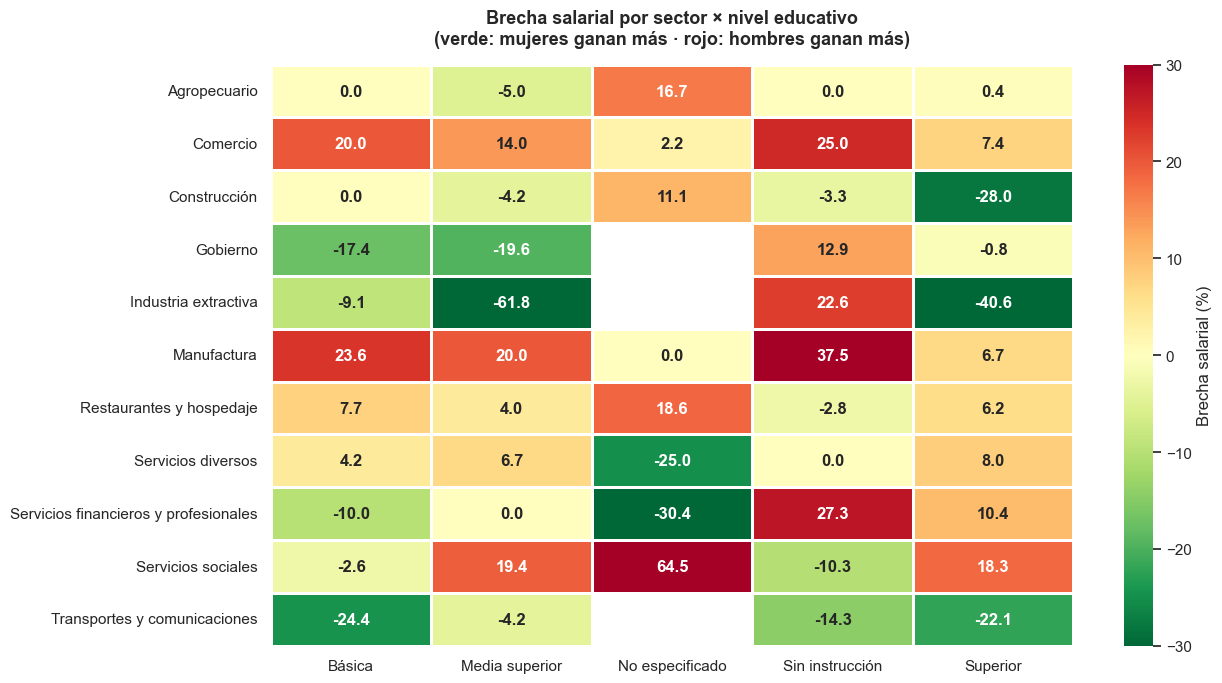

In [10]:
# Preparar matriz: sector en filas, nivel_educ en columnas
if 'brecha_pct' not in bedu.columns:
    # Si no tiene brecha calculada, calcularla
    bedu['brecha_pct'] = ((bedu['Hombre'] - bedu['Mujer']) / bedu['Hombre'] * 100).round(1)

pivot_edu = bedu.pivot_table(
    index='sector',
    columns='nivel_educ',
    values='brecha_pct'
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_edu, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
            vmin=-30, vmax=30,
            cbar_kws={'label': 'Brecha salarial (%)'},
            linewidths=2, linecolor='white',
            annot_kws={'fontweight': 'bold'},
            ax=ax)

ax.set_title('Brecha salarial por sector × nivel educativo\n'
             '(verde: mujeres ganan más · rojo: hombres ganan más)',
             fontsize=13, pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('heatmap_sector_educ.png', dpi=150, bbox_inches='tight')
plt.show()

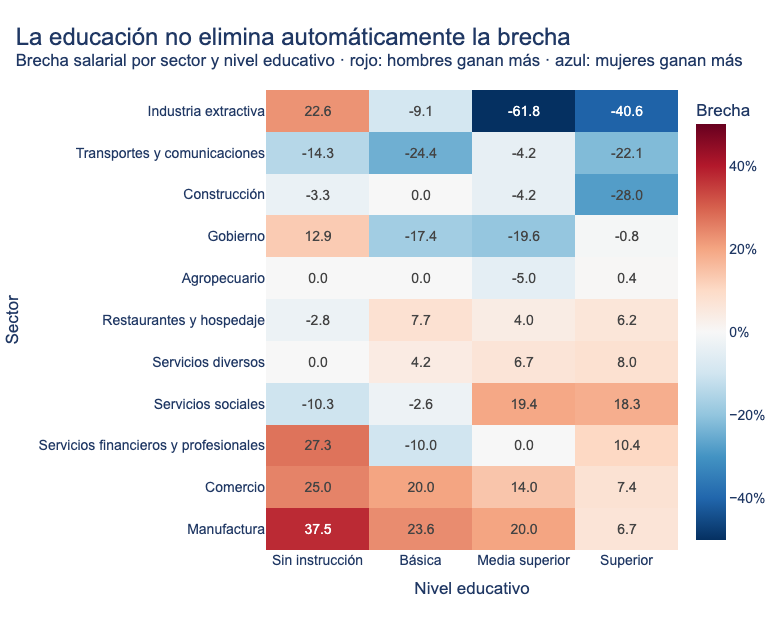

In [8]:
bedu_clean = bedu.copy()

if "brecha_pct" not in bedu_clean.columns:
    bedu_clean["brecha_pct"] = (
        (bedu_clean["Hombre"] - bedu_clean["Mujer"]) / bedu_clean["Hombre"] * 100
    ).round(1)

orden_educ = [
    "Sin instrucción",
    "Básica",
    "Media superior",
    "Superior"
]

bedu_clean = bedu_clean[bedu_clean["nivel_educ"].isin(orden_educ)].copy()
bedu_clean["nivel_educ"] = pd.Categorical(
    bedu_clean["nivel_educ"],
    categories=orden_educ,
    ordered=True
)

pivot_edu = bedu_clean.pivot_table(
    index="sector",
    columns="nivel_educ",
    values="brecha_pct",
    aggfunc="median"
)

# Ordenar sectores por brecha promedio
pivot_edu["_promedio"] = pivot_edu.mean(axis=1)
pivot_edu = pivot_edu.sort_values("_promedio", ascending=True)
pivot_edu = pivot_edu.drop(columns="_promedio")

zmax = min(50, np.nanmax(np.abs(pivot_edu.values)))

fig_heat = px.imshow(
    pivot_edu,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=0,
    zmin=-zmax,
    zmax=zmax,
    labels={
        "x": "Nivel educativo",
        "y": "Sector",
        "color": "Brecha %"
    }
)

fig_heat.update_traces(
    hovertemplate=(
        "<b>Sector:</b> %{y}<br>"
        "<b>Nivel educativo:</b> %{x}<br>"
        "<b>Brecha:</b> %{z:.1f}%"
        "<extra></extra>"
    )
)

fig_heat = estilo_fig(
    fig_heat,
    titulo="La educación no elimina automáticamente la brecha",
    subtitulo="Brecha salarial por sector y nivel educativo · rojo: hombres ganan más · azul: mujeres ganan más",
    alto=620
)

fig_heat.update_xaxes(side="bottom")
fig_heat.update_layout(
    coloraxis_colorbar=dict(
        title="Brecha",
        ticksuffix="%"
    )
)

fig_heat.show(config=FIG_CONFIG)

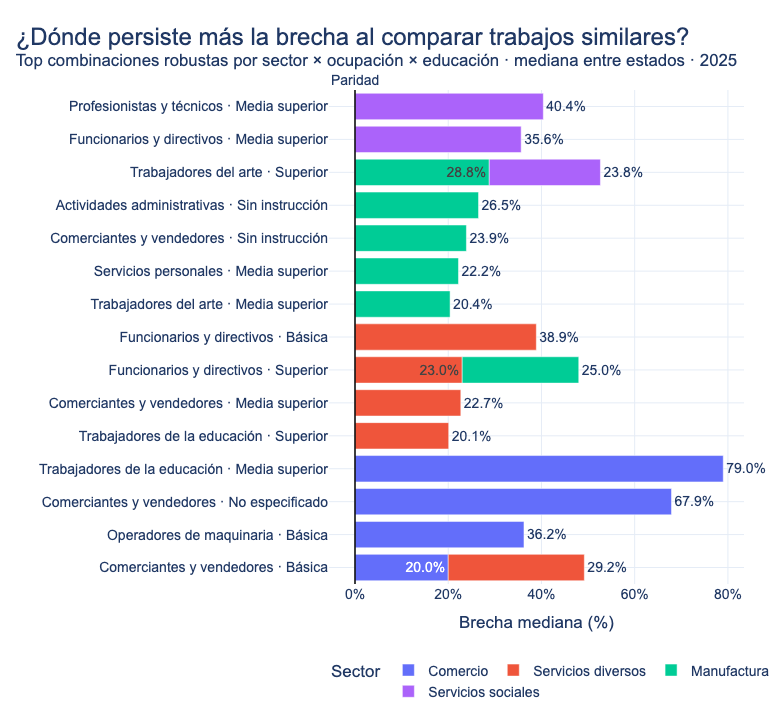

In [9]:
# Sectores prioritarios según tu narrativa
sectores_prioritarios = [
    "Comercio",
    "Manufactura",
    "Restaurantes y hospedaje",
    "Servicios sociales",
    "Servicios diversos"
]

estructural_prior = bestr_clean[
    bestr_clean["sector"].isin(sectores_prioritarios)
].copy()

# Agregar por sector × ocupación × educación usando la mediana entre estados
res_estructural = (
    estructural_prior
    .groupby(["sector", "ocupacion", "nivel_educ"])
    .agg(
        brecha_mediana=("brecha_pct", "median"),
        n_estados=("estado", "nunique"),
        n_combinaciones=("brecha_pct", "size")
    )
    .reset_index()
)

# Filtro de robustez: que aparezca en varios estados
res_estructural = res_estructural[res_estructural["n_estados"] >= 5].copy()

res_estructural["grupo"] = (
    res_estructural["ocupacion"].astype(str)
    + " · "
    + res_estructural["nivel_educ"].astype(str)
)

# Elegir combinaciones más desfavorables para mujeres, pero con filtro de robustez
top_desfav = (
    res_estructural
    .sort_values("brecha_mediana", ascending=False)
    .head(18)
    .copy()
)

top_desfav = top_desfav.sort_values("brecha_mediana", ascending=True)

fig_top_estruct = px.bar(
    top_desfav,
    x="brecha_mediana",
    y="grupo",
    color="sector",
    orientation="h",
    text=top_desfav["brecha_mediana"].round(1).astype(str) + "%",
    labels={
        "brecha_mediana": "Brecha mediana (%)",
        "grupo": "",
        "sector": "Sector"
    },
    hover_data={
        "sector": True,
        "ocupacion": True,
        "nivel_educ": True,
        "brecha_mediana": ":.1f",
        "n_estados": True,
        "n_combinaciones": True,
        "grupo": False
    }
)

fig_top_estruct.add_vline(
    x=0,
    line_color="black",
    line_width=1.5,
    annotation_text="Paridad",
    annotation_position="top"
)

fig_top_estruct.update_traces(
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{customdata[1]}</b><br>"
        "Sector: %{customdata[0]}<br>"
        "Nivel educativo: %{customdata[2]}<br>"
        "Brecha mediana: %{x:.1f}%<br>"
        "Estados donde aparece: %{customdata[4]}<br>"
        "Combinaciones: %{customdata[5]}"
        "<extra></extra>"
    )
)

fig_top_estruct.update_xaxes(
    title="Brecha mediana (%)",
    ticksuffix="%"
)

fig_top_estruct.update_yaxes(title="")

fig_top_estruct = estilo_fig(
    fig_top_estruct,
    titulo="¿Dónde persiste más la brecha al comparar trabajos similares?",
    subtitulo="Top combinaciones robustas por sector × ocupación × educación · mediana entre estados · 2025",
    alto=720
)

fig_top_estruct.show(config=FIG_CONFIG)

In [10]:
display(Markdown(f"""
## Conclusión del análisis posterior

El análisis posterior profundiza el diagnóstico del tablero principal.

Primero, el promedio nacional muestra que la brecha salarial por hora no ha desaparecido entre 2005 y 2025.  
Después, al desagregar por sector, se observa que el problema se concentra en actividades concretas como comercio, manufactura, restaurantes, hospedaje y servicios sociales.

El hallazgo más importante aparece al controlar simultáneamente por:

**estado × sector × ocupación × nivel educativo**

Con este control, se analizaron **{n_validas:,} combinaciones válidas**.  
En **{pct_desfavorables_mujeres:.1f}%** de ellas, los hombres ganan más que las mujeres.

Esto refuerza el eje del ODS 8.5:

> La desigualdad salarial no se explica únicamente por diferencias de educación o sector.  
> La brecha persiste incluso en comparaciones laborales más específicas.

La conexión con el ODS 8.3 aparece cuando estos sectores también presentan condiciones laborales vulnerables, como informalidad o alta concentración de empleo femenino. Por eso, la política pública no debería enfocarse solo en aumentar escolaridad, sino también en transparencia salarial, auditorías por sector, formalización y sistemas de cuidados.
"""))


## Conclusión del análisis posterior

El análisis posterior profundiza el diagnóstico del tablero principal.

Primero, el promedio nacional muestra que la brecha salarial por hora no ha desaparecido entre 2005 y 2025.  
Después, al desagregar por sector, se observa que el problema se concentra en actividades concretas como comercio, manufactura, restaurantes, hospedaje y servicios sociales.

El hallazgo más importante aparece al controlar simultáneamente por:

**estado × sector × ocupación × nivel educativo**

Con este control, se analizaron **3,402 combinaciones válidas**.  
En **57.7%** de ellas, los hombres ganan más que las mujeres.

Esto refuerza el eje del ODS 8.5:

> La desigualdad salarial no se explica únicamente por diferencias de educación o sector.  
> La brecha persiste incluso en comparaciones laborales más específicas.

La conexión con el ODS 8.3 aparece cuando estos sectores también presentan condiciones laborales vulnerables, como informalidad o alta concentración de empleo femenino. Por eso, la política pública no debería enfocarse solo en aumentar escolaridad, sino también en transparencia salarial, auditorías por sector, formalización y sistemas de cuidados.
